In [1]:
# importing libraries
import sklearn
from sklearn.metrics import r2_score


import matplotlib.pyplot as plt
import numpy as np
import csv
import pandas as pd
import shutil

In [2]:
SLEECResults = {}

wfTasks = [1,2,3,4,5,6,7,8,9,10,20,30,40,50,60,70,80,90,100,200,300,400,500,600,700,
           800,900,1000]
currentmax = 1000
while currentmax < 10000:
  currentmax += 250
  wfTasks.append(currentmax)
print(wfTasks)


timeAverages = []
timeVariences = []
for sleecset in [25,125,625]:
  SLEECResults[sleecset] = {}
  for index in range(1,11):

    data = []
    file = "SLEEC" + str(sleecset) + "-" + str(index) + ".csv"
    reader = csv.DictReader(open(file))

    for line in reader:
      SLEECResults[sleecset][index] = line

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 200, 300, 400, 500, 600, 700, 800, 900, 1000, 1250, 1500, 1750, 2000, 2250, 2500, 2750, 3000, 3250, 3500, 3750, 4000, 4250, 4500, 4750, 5000, 5250, 5500, 5750, 6000, 6250, 6500, 6750, 7000, 7250, 7500, 7750, 8000, 8250, 8500, 8750, 9000, 9250, 9500, 9750, 10000]


In [3]:
average25Time = []
variance25Time = []

for position in range(0,64):
  timeResults = []
  for index in range(1,11):
    timeResults.append(list(SLEECResults[25][index].values())[position])
  if len(timeResults) > 0:
    #convert to int, and turn to milliseonds
    timeResults = [int(x)/1000000000 for x in timeResults]
    average25Time.append(np.mean(timeResults))
    variance25Time.append(np.var(timeResults))

average125Time = []
variance125Time = []

for position in range(0,64):
  timeResults = []
  for index in range(1,11):
    timeResults.append(list(SLEECResults[125][index].values())[position])
  if len(timeResults) > 0:

    timeResults = [int(x)/1000000000 for x in timeResults]
    average125Time.append(np.mean(timeResults))
    variance125Time.append(np.var(timeResults))


average625Time = []
variance625Time = []

for position in range(0,64):
  timeResults = []
  for index in range(1,11):
    timeResults.append(list(SLEECResults[625][index].values())[position])
  if len(timeResults) > 0:
    timeResults = [int(x)/1000000000 for x in timeResults]
    average625Time.append(np.mean(timeResults))
    variance625Time.append(np.var(timeResults))

Average sample: [np.float64(5.8663300000000005e-05), np.float64(8.39502e-05), np.float64(7.4063e-06)]
Variance sample: [np.float64(2.8844891037010002e-08), np.float64(5.829492297195999e-08), np.float64(9.489004581e-11)]


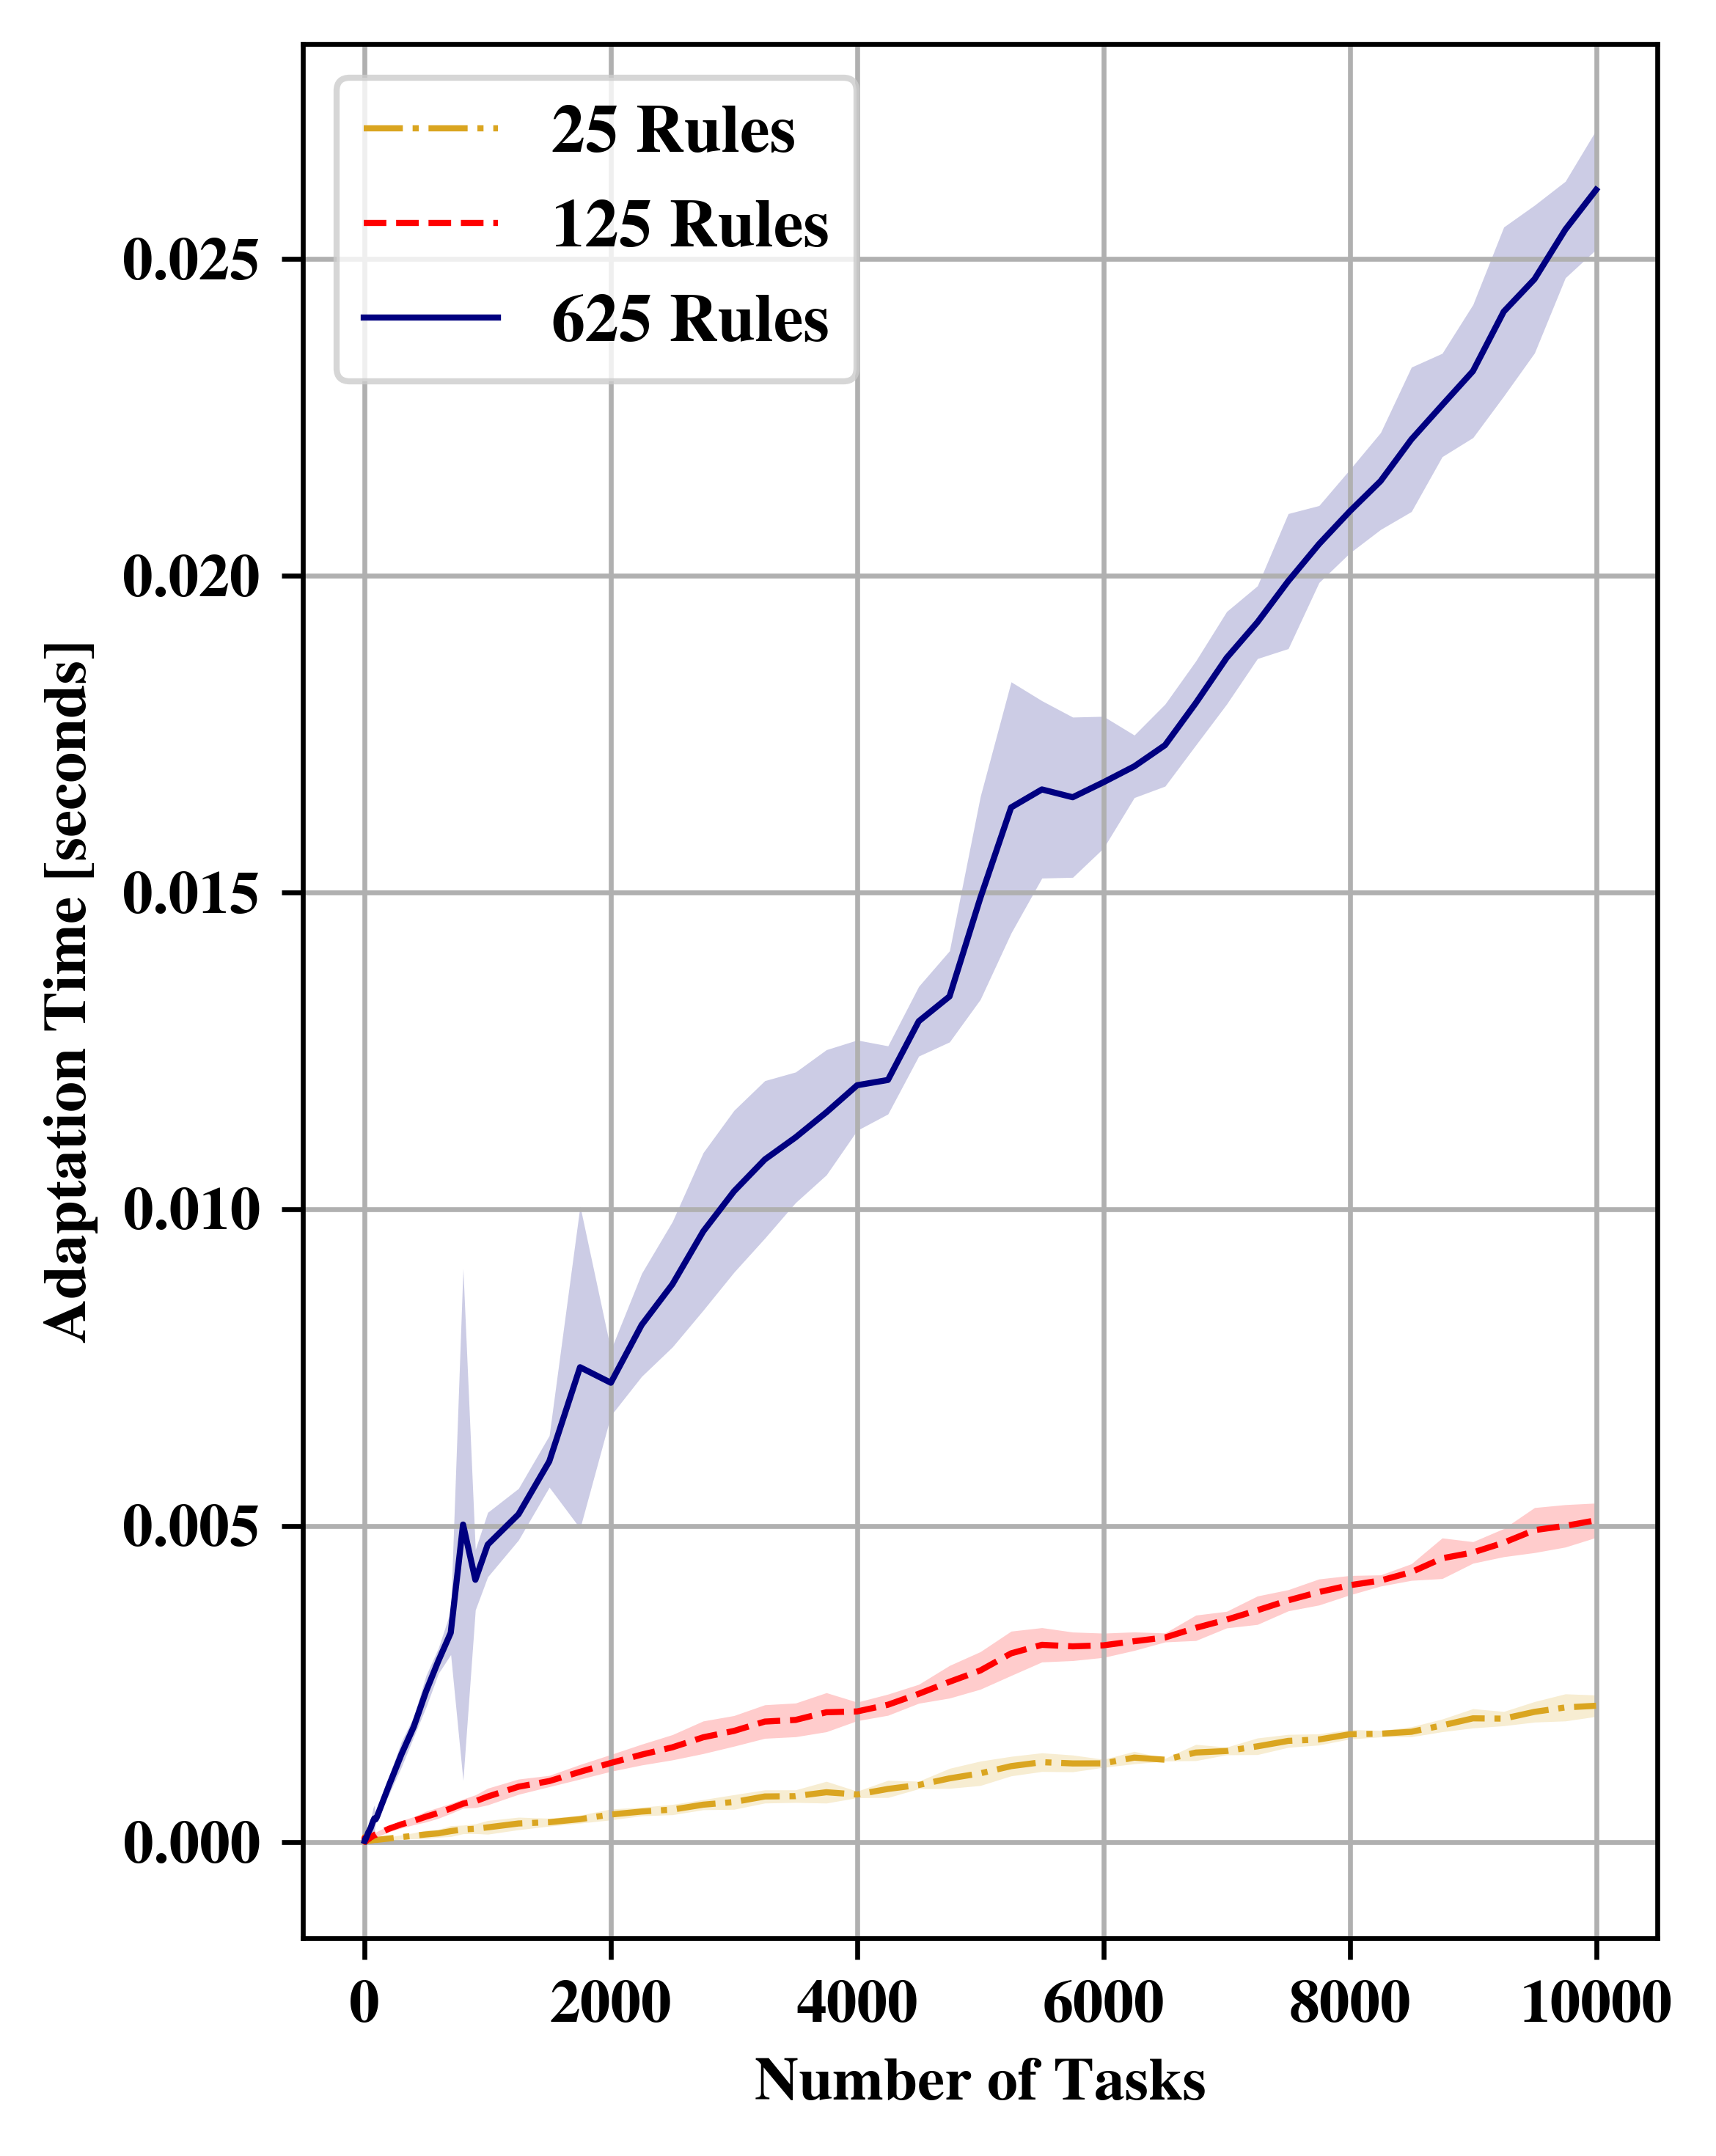

In [4]:
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['axes.labelweight'] = 'bold'

# 1. Use a smaller physical canvas size (keeps the 1:1.25 ratio)
fig, ax = plt.subplots(figsize=(4, 5), dpi=600)

plt.rcParams.update({
    'font.size': 10,          # For tick numbers (0, 100, 200...)
    'axes.labelsize': 14,     # For "Number of Tasks", etc.
    'legend.fontsize': 11     # For the legend box
})

fig.dpi = 600
ax.grid(True)
ax.plot(wfTasks,average25Time,'-.',label="25 Rules",color='goldenrod',lw=1)
ax.plot(wfTasks,average125Time,'--',label="125 Rules",color='red',lw=1)
ax.plot(wfTasks,average625Time,'-',color='navy',label="625 Rules",lw=1)
ax.set_xlabel("Number of Tasks")
ax.set_ylabel("Adaptation Time [seconds]")



wfTasks_arr = np.array(wfTasks)
avg_arr = np.array(average25Time)
var_arr = np.array(variance25Time)  # Your variance list

avg_25 = np.array(average25Time)
var_25 = np.array(variance25Time)

# 2. Calculate Standard Deviation (Square root of variance)
std_25 = np.sqrt(var_25)

# 3. Plot the line

# 4. Fill between using Standard Deviation instead of Variance
ax.fill_between(
    wfTasks,
    avg_25 - std_25,
    avg_25 + std_25,
    color='goldenrod',
    alpha=0.2,
    linewidth=0
)




wfTasks_arr = np.array(wfTasks)
avg_arr = np.array(average125Time)
var_arr = np.array(variance125Time)  # Your variance list

avg_125 = np.array(average125Time)
var_125 = np.array(variance125Time)

# 2. Calculate Standard Deviation (Square root of variance)
std_125 = np.sqrt(var_125)

# 3. Plot the line

# 4. Fill between using Standard Deviation instead of Variance
ax.fill_between(
    wfTasks,
    avg_125 - std_125,
    avg_125 + std_125,
    color='red',
    alpha=0.2,
    linewidth=0
)



wfTasks_arr = np.array(wfTasks)
avg_arr = np.array(average625Time)
var_arr = np.array(variance625Time)  # Your variance list

avg_625 = np.array(average625Time)
var_625 = np.array(variance625Time)

# 2. Calculate Standard Deviation (Square root of variance)
std_625 = np.sqrt(var_625)

# 3. Plot the line

# 4. Fill between using Standard Deviation instead of Variance
ax.fill_between(
    wfTasks,
    avg_625 - std_625,
    avg_625 + std_625,
    color='navy',
    alpha=0.2,
    linewidth=0
)
print("Average sample:", average25Time[:3])
print("Variance sample:", variance25Time[:3])

plt.legend(loc='upper left')

fig.tight_layout()
plt.savefig("plot1.pdf", format="pdf") #